INSTALL LIBRARY SASTRAWI

In [ ]:
!pip install Sastrawi openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.9 MB/s eta 0:00:00


IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

LOAD DATASET

In [ ]:
df = pd.read_excel('/content/dataset_final_mbg.xlsx')

In [ ]:
df.head()

,Timestamp,KESEGARAN,LABEL KESEGARAN,GIZI,LABEL GIZI,RASA,LABEL RASA,PORSI,LABEL PORSI
0,2026-05-26 10:29:14.620,cukup segar dan lumayan enak walau kadang ada ...,-1,cukup karena dalam satu waktu memiliki banyak ...,1,enak dan program mbg cukup membantu,1,cukup,1
1,2026-05-26 10:32:28.612,"kadang segar, kadang ada yang asem bu, buahnya...",-1,sudah sesuai 4 sehat 5 sempurna,1,"kadang ada yang hambar, dan kecut",-1,sudah pas,1
2,2026-05-26 10:33:50.958,"terkadang segar, terkadang udah agak asem/bau ...",-1,menurut saya kurang memenuhi asupan gizi haria...,-1,"tergantung sppg, kadang enak kadang engga. ya ...",-1,"cukup buat sekali makan, nasi nya pas, lauknya...",1
3,2026-05-26 10:35:44.330,kadang segar kadang engga,0,enak bergizi,1,kadang enak kadang engga,0,porsinya kurang,-1
4,2026-05-26 10:37:15.914,Cukup segar,1,kandungan gizinya seimbang,1,"rasa makan enak, kaya rasa",1,porsinya cukup dan pas,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Timestamp        169 non-null    datetime64[ns]
 1   KESEGARAN        169 non-null    object        
 2   LABEL KESEGARAN  169 non-null    int64         
 3   GIZI             169 non-null    object        
 4   LABEL GIZI       169 non-null    int64         
 5   RASA             169 non-null    object        
 6   LABEL RASA       169 non-null    int64         
 7   PORSI            169 non-null    object        
 8   LABEL PORSI      169 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 12.0+ KB


CEK MISSING VALUE

In [ ]:
df.isnull().sum()

,0
Timestamp,0
KESEGARAN,0
LABEL KESEGARAN,0
GIZI,0
LABEL GIZI,0
RASA,0
LABEL RASA,0
PORSI,0
LABEL PORSI,0


CEK DISTRIBUSI DATA PADA TIAP ASPEK

In [ ]:
data_kesegaran = df[['KESEGARAN', 'LABEL KESEGARAN']].copy()
data_kesegaran.columns = ['text', 'label']

data_kesegaran['label'].value_counts()

,count
label,
-1,75
1,62
0,32


In [ ]:
data_gizi = df[['GIZI', 'LABEL GIZI']].copy()
data_gizi.columns = ['text', 'label']

data_gizi['label'].value_counts()

,count
label,
1,99
-1,48
0,22


In [ ]:
data = df[['RASA', 'LABEL RASA']].copy()
data.columns = ['text', 'label']

data['label'].value_counts()

,count
label,
1,65
0,54
-1,50


In [ ]:
data_porsi = df[['PORSI', 'LABEL PORSI']].copy()
data_porsi.columns = ['text', 'label']

data_porsi['label'].value_counts()

,count
label,
1,106
-1,50
0,13


MEMILIH ASPEK DAN MENJAGA DATA ASLI

In [ ]:
ASPEK = 'KESEGARAN'
LABEL = 'LABEL KESEGARAN'

data = df[[ASPEK, LABEL]].copy()
data.columns = ['text', 'label']

# Simpan teks asli
data['text_asli'] = data['text']

PREPROCESSING

In [ ]:
# Case Folding

data['text_before_casefold'] = data['text']

data['text_clean'] = data['text'].str.lower()

hasil_casefold = data[
    data['text_before_casefold'] != data['text_clean']
][['text_before_casefold', 'text_clean']]

hasil_casefold.head(10)

,text_before_casefold,text_clean
4,Cukup segar,cukup segar
5,Kadang-kadang segar doang,kadang-kadang segar doang
11,"Sedikit kurang, terlebih untuk makanan yang be...","sedikit kurang, terlebih untuk makanan yang be..."
13,Pas datang biasanya itu kurang fresh/agak hambar,pas datang biasanya itu kurang fresh/agak hambar
16,Pendapat saya mengenai kesegaran makanan yang ...,pendapat saya mengenai kesegaran makanan yang ...
20,"Biasa saja, terkadang segar, terkadang juga ti...","biasa saja, terkadang segar, terkadang juga ti..."
23,Lumayan,lumayan
24,Menurut saya kurang Segar,menurut saya kurang segar
26,kesegaran makanan dalam program MBG menurut sa...,kesegaran makanan dalam program mbg menurut sa...
30,Makanan nya sangat fresh,makanan nya sangat fresh


In [ ]:
# Cleaning

def cleaning(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Simpan sebelum cleaning
data['text_before_cleaning'] = data['text_clean']

# Cleaning
data['text_clean'] = data['text_clean'].apply(cleaning)

hasil_cleaning = data[
    data['text_before_cleaning'] != data['text_clean']
][['text_before_cleaning', 'text_clean']]

hasil_cleaning.head(10)

,text_before_cleaning,text_clean
1,"kadang segar, kadang ada yang asem bu, buahnya...",kadang segar kadang ada yang asem bu buahnya j...
2,"terkadang segar, terkadang udah agak asem/bau ...",terkadang segar terkadang udah agak asem bau asem
4,cukup segar,cukup segar
5,kadang-kadang segar doang,kadang kadang segar doang
7,ga selalu segar terkadang ada sayur yang sudah...,ga selalu segar terkadang ada sayur yang sudah...
10,"cukup segar, tetapi kadang ada sayuran yang ka...",cukup segar tetapi kadang ada sayuran yang kad...
11,"sedikit kurang, terlebih untuk makanan yang be...",sedikit kurang terlebih untuk makanan yang ber...
12,"sayur layu, kurang segar, nasi keras, lauk asem",sayur layu kurang segar nasi keras lauk asem
13,pas datang biasanya itu kurang fresh/agak hambar,pas datang biasanya itu kurang fresh agak hambar
14,"kurang segar, buah nya jeruk pisang terus, mie...",kurang segar buah nya jeruk pisang terus mie a...


In [ ]:
# Normalisasi

normalisasi = {

    # ========================
    # NEGASI
    # ========================
    'ga':'tidak',
    'gak':'tidak',
    'gk':'tidak',
    'ngga':'tidak',
    'nggak':'tidak',
    'engga':'tidak',
    'enggak':'tidak',
    'tdk':'tidak',

    # Frasa negatif
    'gaenak':'tidak enak',
    'g enak':'tidak enak',
    'ga enak':'tidak enak',
    'gak enak':'tidak enak',
    'ngga enak':'tidak enak',
    'nggak enak':'tidak enak',

    'gabagus':'tidak bagus',
    'ga bagus':'tidak bagus',
    'g bagus':'tidak bagus',
    'gak bagus':'tidak bagus',


    # ========================
    # SAMBUNG
    # ========================
    'tp':'tetapi',
    'tpi':'tetapi',
    'b aja': 'biasa saja',
    'biasa aja': 'biasa saja',

    # ========================
    # UMUM
    # ========================
    'yg':'yang',
    'utk':'untuk',
    'dr':'dari',
    'dgn':'dengan',
    'krn':'karena',
    'krna':'karena',
    'dn':'dan',

    'trs':'terus',
    'trus':'terus',

    'sdh':'sudah',
    'udh':'sudah',
    'udah':'sudah',

    'blm':'belum',

    # ========================
    # KATA SEHARI-HARI
    # ========================
    'aja':'saja',
    'doang':'saja',

    'klo':'kalau',
    'kalo':'kalau',

    'kyk':'seperti',
    'kayak':'seperti',
    'kaya':'seperti',

    'ama':'sama',
    'seger':'segar',

    # ========================
    # ORANG
    # ========================
    'gw':'saya',
    'gua':'saya',
    'gue':'saya',

    'lu':'kamu',
    'loe':'kamu',

    # ========================
    # PENEGAS
    # ========================
    'bgt':'banget',
    'bngt':'banget',

    # ========================
    # TYPO
    # ========================
    'enakk':'enak',
    'enakkk':'enak',
    'enaaak':'enak',

    'baguss':'bagus',
    'bagusss':'bagus',

    'lumayann':'lumayan',

    'kureng':'kurang',

    # ========================
    # EKSPRESI
    # ========================
    'huek':'tidak enak',
    'huekk':'tidak enak',
    'huwek':'tidak enak',

    # ========================
    # LAINNYA
    # ========================
    'gaada':'tidak ada',
    'gada':'tidak ada',

    'gatau':'tidak tahu',

    'gapapa':'tidak apa apa',

    'gmn':'bagaimana',

    'gt':'begitu',
    'gtu':'begitu',
    'gitu':'begitu',

    'mbg':'makan bergizi gratis',

    'ompreng':'kotak makan',

    'okesih':'oke',
    'okee':'oke',
    'okee':'oke',
    'ok':'oke',
    'ok sih':'oke',

    # Kata pengisi
    'jir':'',
    'bjir':'',
    'anjir':'',
    'wkwk':'',
    'wkwkwk':'',
    'hehe':'',
    'wk':'',

    'nih':'',
    'deh':'',
    'dong':'',
    'lah':''
}

def normalisasi_text(text):
    for key, value in normalisasi.items():
        text = re.sub(r'\b' + re.escape(key) + r'\b', value, text)
    return text

# Simpan hasil sebelum normalisasi
data['text_before_normalisasi'] = data['text_clean']

# Jalankan normalisasi
data['text_clean'] = data['text_clean'].apply(normalisasi_text)

# Tampilkan hanya data yang berubah
hasil_normalisasi = data[
    data['text_before_normalisasi'] != data['text_clean']
][['text_before_normalisasi', 'text_clean']]

hasil_normalisasi.head(10)

,text_before_normalisasi,text_clean
2,terkadang segar terkadang udah agak asem bau asem,terkadang segar terkadang sudah agak asem bau ...
3,kadang segar kadang engga,kadang segar kadang tidak
5,kadang kadang segar doang,kadang kadang segar saja
7,ga selalu segar terkadang ada sayur yang sudah...,tidak selalu segar terkadang ada sayur yang su...
9,lumayan lah,lumayan
14,kurang segar buah nya jeruk pisang terus mie a...,kurang segar buah nya jeruk pisang terus mie a...
21,baik kaya baru dimasak pagi buta,baik seperti baru dimasak pagi buta
26,kesegaran makanan dalam program mbg menurut sa...,kesegaran makanan dalam program makan bergizi ...
28,kadang ad yg kurnag segar,kadang ad yang kurnag segar
29,saya selalu menyukai mbg dengan kondisi segar ...,saya selalu menyukai makan bergizi gratis deng...


In [ ]:
# =========================
# TOKENIZING
# =========================

# Simpan sebelum tokenisasi
data['text_before_tokenisasi'] = data['text_clean']

# Tokenisasi
data['tokens'] = data['text_clean'].apply(lambda x: x.split())

# Before & After
hasil_tokenisasi = data[['text_before_tokenisasi','tokens']]

hasil_tokenisasi.head(10)

,text_before_tokenisasi,tokens
0,cukup segar dan lumayan enak walau kadang ada ...,"[cukup, segar, dan, lumayan, enak, walau, kada..."
1,kadang segar kadang ada yang asem bu buahnya j...,"[kadang, segar, kadang, ada, yang, asem, bu, b..."
2,terkadang segar terkadang sudah agak asem bau ...,"[terkadang, segar, terkadang, sudah, agak, ase..."
3,kadang segar kadang tidak,"[kadang, segar, kadang, tidak]"
4,cukup segar,"[cukup, segar]"
5,kadang kadang segar saja,"[kadang, kadang, segar, saja]"
6,lumayan segar,"[lumayan, segar]"
7,tidak selalu segar terkadang ada sayur yang su...,"[tidak, selalu, segar, terkadang, ada, sayur, ..."
8,ya cukup enak tetapi terkadang agak bau,"[ya, cukup, enak, tetapi, terkadang, agak, bau]"
9,lumayan,[lumayan]


In [ ]:
# =========================
# STOPWORD REMOVAL
# =========================

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stop_words = set(factory.get_stop_words())

keep_words = {

    'tidak',
    'bukan',
    'belum',
    'kurang',

    'kadang',
    'terkadang',
    'sering',

    'cukup',
    'lumayan',
    'lebih',
    'sangat',

    'baik',
    'bagus',
    'buruk',
    'jelek',

    'tetapi',
    'namun',

    'pas',
    'banyak',
    'sedikit'
}

stop_words = stop_words - keep_words

# Simpan sebelum stopword removal
data['tokens_before_stopword'] = data['tokens'].apply(lambda x: x.copy())

# Stopword Removal
data['tokens'] = data['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

# Tampilkan hanya yang berubah
hasil_stopword = data[
    data['tokens_before_stopword'].astype(str) != data['tokens'].astype(str)
][['tokens_before_stopword','tokens']]

hasil_stopword.head(10)

,tokens_before_stopword,tokens
0,"[cukup, segar, dan, lumayan, enak, walau, kada...","[cukup, segar, lumayan, enak, kadang, basi, se..."
1,"[kadang, segar, kadang, ada, yang, asem, bu, b...","[kadang, segar, kadang, asem, bu, buahnya, kad..."
2,"[terkadang, segar, terkadang, sudah, agak, ase...","[terkadang, segar, terkadang, asem, bau, asem]"
5,"[kadang, kadang, segar, saja]","[kadang, kadang, segar]"
7,"[tidak, selalu, segar, terkadang, ada, sayur, ...","[tidak, selalu, segar, terkadang, sayur, asam,..."
8,"[ya, cukup, enak, tetapi, terkadang, agak, bau]","[cukup, enak, tetapi, terkadang, bau]"
10,"[cukup, segar, tetapi, kadang, ada, sayuran, y...","[cukup, segar, tetapi, kadang, sayuran, kadalu..."
11,"[sedikit, kurang, terlebih, untuk, makanan, ya...","[sedikit, kurang, terlebih, makanan, berkuah, ..."
13,"[pas, datang, biasanya, itu, kurang, fresh, ag...","[pas, datang, biasanya, kurang, fresh, hambar]"
14,"[kurang, segar, buah, nya, jeruk, pisang, teru...","[kurang, segar, buah, nya, jeruk, pisang, teru..."


In [ ]:
# =========================
# STEMMING
# =========================

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Simpan sebelum stemming
data['text_before_stemming'] = data['tokens'].apply(lambda x: ' '.join(x))

# Stemming
data['text_stemming'] = data['tokens'].apply(
    lambda words: ' '.join(stemmer.stem(word) for word in words)
)

# Tampilkan hanya yang berubah
hasil_stemming = data[
    data['text_before_stemming'] != data['text_stemming']
][['text_before_stemming','text_stemming']]

hasil_stemming.head(10)

,text_before_stemming,text_stemming
0,cukup segar lumayan enak kadang basi semacamnya,cukup segar lumayan enak kadang basi macam
1,kadang segar kadang asem bu buahnya kadang kur...,kadang segar kadang asem bu buah kadang kurang...
7,tidak selalu segar terkadang sayur asam bahkan...,tidak selalu segar terkadang sayur asam bahkan...
10,cukup segar tetapi kadang sayuran kadaluarsa,cukup segar tetapi kadang sayur kadaluarsa
11,sedikit kurang terlebih makanan berkuah khusus...,sedikit kurang lebih makan kuah khusus sayur s...
13,pas datang biasanya kurang fresh hambar,pas datang biasa kurang fresh hambar
16,pendapat mengenai kesegaran makanan disajikan ...,dapat kena segar makan saji ada tengah tengah ...
17,terkadang segar terkadang tidak segar bahkan b...,terkadang segar terkadang tidak segar bahkan b...
19,kesegaran sajikan terlihat bagus terlihat laya...,segar saji lihat bagus lihat layak makan tidak...
21,baik baru dimasak pagi buta,baik baru masak pagi buta


MENAMPILKAN 50 DATA SECARA ACAK

In [ ]:
data[['text_asli',
      'text_clean',
      'tokens',
      'text_stemming',
      'label']].sample(50, random_state=42)

,text_asli,text_clean,tokens,text_stemming,label
138,terkadang sayurnya ga segar dan hambar,terkadang sayurnya tidak segar dan hambar,"[terkadang, sayurnya, tidak, segar, hambar]",terkadang sayur tidak segar hambar,-1
30,Makanan nya sangat fresh,makanan nya sangat fresh,"[makanan, nya, sangat, fresh]",makan nya sangat fresh,1
119,bagus,bagus,[bagus],bagus,1
29,"saya selalu menyukai mbg dengan kondisi segar,...",saya selalu menyukai makan bergizi gratis deng...,"[selalu, menyukai, makan, bergizi, gratis, kon...",selalu suka makan gizi gratis kondisi segar ke...,1
143,Segar selalu,segar selalu,"[segar, selalu]",segar selalu,1
162,keren,keren,[keren],keren,1
165,sangat bergantung pada penerapan standar opera...,sangat bergantung pada penerapan standar opera...,"[sangat, bergantung, penerapan, standar, opera...",sangat gantung terap standar operasional satu ...,0
51,kurang terkadang basi,kurang terkadang basi,"[kurang, terkadang, basi]",kurang terkadang basi,-1
105,lumayan,lumayan,[lumayan],lumayan,1
60,"baik, tidak ada yg cacat selama saya mengonsumsi",baik tidak ada yang cacat selama saya mengonsumsi,"[baik, tidak, cacat, selama, mengonsumsi]",baik tidak cacat lama konsumsi,1


MEMBAGI DATA LATIH & DATA UJI

In [ ]:
X = data['text_stemming']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

TF IDF

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(135, 203)
(34, 203)


KATA YG DIPELAJARI OLEH TF IDF

In [ ]:
print(vectorizer.get_feature_names_out())

['ad' 'ada' 'akhir' 'alhamdulillah' 'aman' 'anak' 'aneh' 'anggur' 'apa'
 'aroma' 'asa' 'asam' 'asem' 'awal' 'ayam' 'bagi' 'bagus' 'bahkan' 'baik'
 'banget' 'banyak' 'baru' 'basi' 'bau' 'be' 'beberapa' 'beda' 'belum'
 'benar' 'benda' 'bersih' 'besar' 'better' 'biasa' 'buah' 'buang' 'buat'
 'buruk' 'busuk' 'buta' 'cair' 'cegah' 'cm' 'contog' 'cukup' 'cuma'
 'cuman' 'daging' 'dalam' 'dapat' 'datang' 'didiemin' 'dimbg' 'dingin'
 'dini' 'distribusi' 'dpt' 'dri' 'enak' 'fifty' 'fresh' 'gantung'
 'gituloh' 'gizi' 'goreng' 'gratis' 'hambar' 'hampir' 'hangat' 'hari'
 'higienis' 'hijau' 'hingga' 'ih' 'iya' 'jadi' 'jaga' 'jam' 'jangan'
 'jeruk' 'kadaluarsa' 'kadang' 'kagak' 'kalau' 'kali' 'karna' 'kasih'
 'kecoa' 'keluar' 'kematengan' 'kena' 'kentel' 'kenyang' 'keras' 'keren'
 'khusus' 'kok' 'kondisi' 'konsumsi' 'kotak' 'krusial' 'kuah' 'kualitas'
 'kuning' 'kurang' 'kurnag' 'kurng' 'lahap' 'lama' 'lauk' 'layak' 'layu'
 'lebih' 'lembek' 'lendir' 'lezat' 'liat' 'lihat' 'lumayan' 'macam'
 'makan' '

In [ ]:
print(data['label'].value_counts())

label
-1    75
 1    62
 0    32
Name: count, dtype: int64


PEMODELAN LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test_tfidf)

AKURASI

In [ ]:
from sklearn.metrics import accuracy_score

# Prediksi data train
y_train_pred = model.predict(X_train_tfidf)

# Prediksi data test
y_test_pred = model.predict(X_test_tfidf)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

Training Accuracy : 0.9111111111111111
Testing Accuracy  : 0.7352941176470589


CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.81      0.87      0.84        15
           0       0.00      0.00      0.00         6
           1       0.75      0.92      0.83        13

    accuracy                           0.74        34
   macro avg       0.52      0.60      0.56        34
weighted avg       0.65      0.74      0.69        34



CONFUSION MATRIX

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[13  1  1]
 [ 3  0  3]
 [ 0  1 12]]


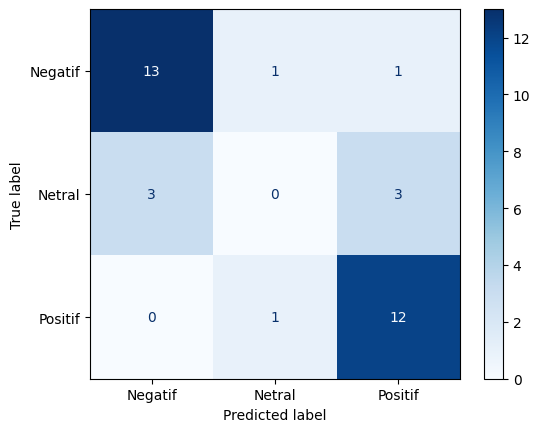

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_tfidf,
    y_test,
    display_labels=['Negatif','Netral','Positif'],
    cmap='Blues'
)

plt.show()

5 FOLD CROSS VALIDATION

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', model)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Accuracy tiap fold :", scores)
print("Rata-rata Accuracy :", scores.mean())
print("Standar Deviasi    :", scores.std())

Accuracy tiap fold : [0.70588235 0.82352941 0.76470588 0.76470588 0.75757576]
Rata-rata Accuracy : 0.7632798573975045
Standar Deviasi    : 0.03731242733563189


In [ ]:
def prediksi_sentimen(kalimat):
    # preprocessing
    kalimat = kalimat.lower()
    kalimat = cleaning(kalimat)
    kalimat = normalisasi_text(kalimat)

    tokens = kalimat.split()
    tokens = [kata for kata in tokens if kata not in stop_words]

    stemmed = ' '.join(stemmer.stem(kata) for kata in tokens)

    # TF-IDF
    vector = vectorizer.transform([stemmed])

    # Prediksi
    hasil = model.predict(vector)[0]

    if hasil == -1:
        return "Negatif"
    elif hasil == 0:
        return "Netral"
    else:
        return "Positif"

In [ ]:
kalimat = input("Masukkan kalimat: ")

print("Prediksi:", prediksi_sentimen(kalimat))

Masukkan kalimat: basi
Prediksi: Negatif
